# Comparison of current using different parameters

In [6]:
import numpy as np
import matplotlib.pyplot as plt
dt = 5e-11

def plot_settings():
    plt.figure(figsize=(10, 6))
    plt.title("Total Current Over Time (Run 1 - 4)")
    plt.xlabel("Time (s)")
    plt.ylabel('Total Current (C)')
    plt.grid()
    plt.tight_layout()

def load_currents(runs, species, dt):
    currents = {}
    for run in runs:
        for spec in species:
            data = np.loadtxt(f'current/{run}/current{spec}.dat')
            time = data[:, 0] * dt
            currents[f"{run}_{spec}"] = data[:, 1] * dt
    return currents

def load_currents_na(runs, dt):
    currents = {}
    for run in runs:
        data = np.loadtxt(f'current/NaCl/{run}/currentSOD-10.dat')
        time = data[:, 0] * dt
        currents[f"{run}_SOD-10"] = data[:, 1] * dt
    return currents

def new_current(file,label,event): 
    data = np.loadtxt(f"post-processing/{file}")
    time = data[:, 0] * dt
    current = data[:, 1] * dt 
    plt.plot(time, current, label=f'{label}, {event} events')

    current_data[label] = current

In [3]:
runs = ['run1', 'run2', 'run3', 'run4']
species = ['NH4-10', 'CLA-10']
currents = load_currents(runs, species, dt)

nh4_currents = []
na_currents = []
cl_currents = []
runs_na = ['run1', 'run2', 'run3', 'run4', 'run5', 'run6', 'run7']
currents_na = load_currents_na(runs_na, dt)

for run in runs:
    nh4_currents.append(currents[f"{run}_NH4-10"])
    cl_currents.append(currents[f"{run}_CLA-10"])

for run in runs_na:
    na_currents.append(currents_na[f"{run}_SOD-10"])

cl_currents = np.array(cl_currents)
nh4_currents = np.array(nh4_currents)
na_currents = np.array(na_currents)

average_nh4_current = np.mean(nh4_currents, axis=0)
average_cl_current = np.mean(cl_currents, axis=0)
average_na_current = np.mean(na_currents, axis=0)

time_steps = np.arange(0, len(average_nh4_current) * dt, dt)

currents = load_currents(runs, species, dt)

labels = [
    ('run3_CLA-10', 'Cl- charge (Run 3), 367 events'),
    ('run4_CLA-10', 'Cl- charge (Run 4), 366 events'),
    ('run1_CLA-10', 'Cl- charge (Run 1), 346 events'),
    ('run2_CLA-10', 'Cl- charge (Run 2), 325 events'),
    ('run4_NH4-10', 'NH4+ charge (Run 4), 156 events'),
    ('run3_NH4-10', 'NH4+ charge (Run 3), 124 events'),
    ('run2_NH4-10', 'NH4+ charge (Run 2), 121 events'),
    ('run1_NH4-10', 'NH4+ charge (Run 1), 116 events')
]
time_steps = np.arange(0, len(currents['run1_CLA-10']) * dt, dt)

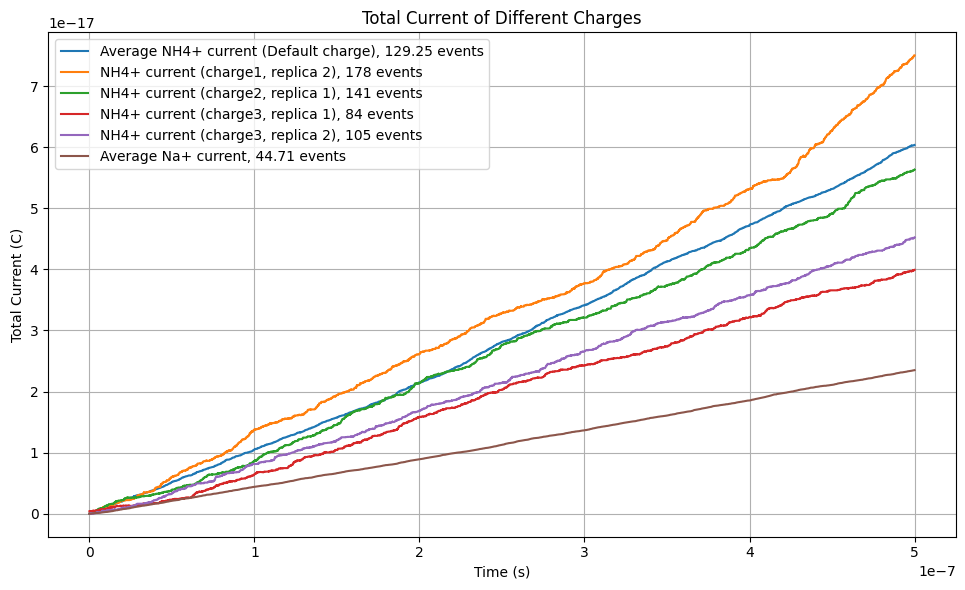

In [22]:
current_data = {}

plot_settings()
plt.plot(time_steps, average_nh4_current, label='Average NH4+ current (Default charge), 129.25 events')
new_current("analysis-run1.2/current/currentNH4-10.dat","NH4+ current (charge1, replica 2)","178")
new_current("analysis-run2.1/current/currentNH4-10.dat","NH4+ current (charge2, replica 1)", "141")
new_current("analysis-run3.1/current/currentNH4-10.dat","NH4+ current (charge3, replica 1)", "84")
new_current("analysis-run3.2/current/currentNH4-10.dat","NH4+ current (charge3, replica 2)", "105")
plt.plot(time_steps, average_na_current, label='Average Na+ current, 44.71 events')

plt.legend()
plt.title('Total Current of Different Charges')
plt.show()

In [12]:
degree = 1 
voltage = 1.37

def conductance(current):
    params, cov = np.polyfit(time_steps, current, degree, cov=True)
    m, c = params
    perr = np.sqrt(np.diag(cov))
    print("Gradient (m) and intercept (c) of the best-fit line:")
    print(f" m (Average current) = {m} A ± {perr[0]} A")  # Error on m
    print(f" c = {c} C ± {perr[1]} C")  # Error on c
    voltage = 1.37
    conductance = m / voltage
    print(f"Conductance = {conductance} S")

print("NH4+(Charge 0)_________________________________________________")
conductance(average_nh4_current)
print("NH4+(Charge 1)_________________________________________________")
conductance(current_data["NH4+ current (charge1, replica 2)"])
print("NH4+(Charge 2)_________________________________________________")
conductance(current_data["NH4+ current (charge2, replica 1)"])
print("NH4+(Charge 3, replica 1)_________________________________________________")
conductance(current_data["NH4+ current (charge3, replica 1)"])
print("NH4+(Charge 3, replica 2)_________________________________________________")
conductance(current_data["NH4+ current (charge3, replica 2)"])

NH4+(Charge 0)_________________________________________________
Gradient (m) and intercept (c) of the best-fit line:
 m (Average current) = 1.2193108115597355e-10 A ± 5.451490678116009e-14 A
 c = -1.829214360348742e-18 C ± 1.5737491475008702e-20 C
Conductance = 8.900078916494418e-11 S
NH4+(Charge 1)_________________________________________________
Gradient (m) and intercept (c) of the best-fit line:
 m (Average current) = 1.40314805238799e-10 A ± 1.3269756322568295e-13 A
 c = -1.9013313596070153e-18 C ± 3.8307444574780463e-20 C
Conductance = 1.024195658677365e-10 S
NH4+(Charge 2)_________________________________________________
Gradient (m) and intercept (c) of the best-fit line:
 m (Average current) = 1.1394456854518052e-10 A ± 5.1946901542165166e-14 A
 c = -1.7257068186587174e-18 C ± 1.499615368425186e-20 C
Conductance = 8.317121791619015e-11 S
NH4+(Charge 3, replica 1)_________________________________________________
Gradient (m) and intercept (c) of the best-fit line:
 m (Average c

# 1. RMSD analysis

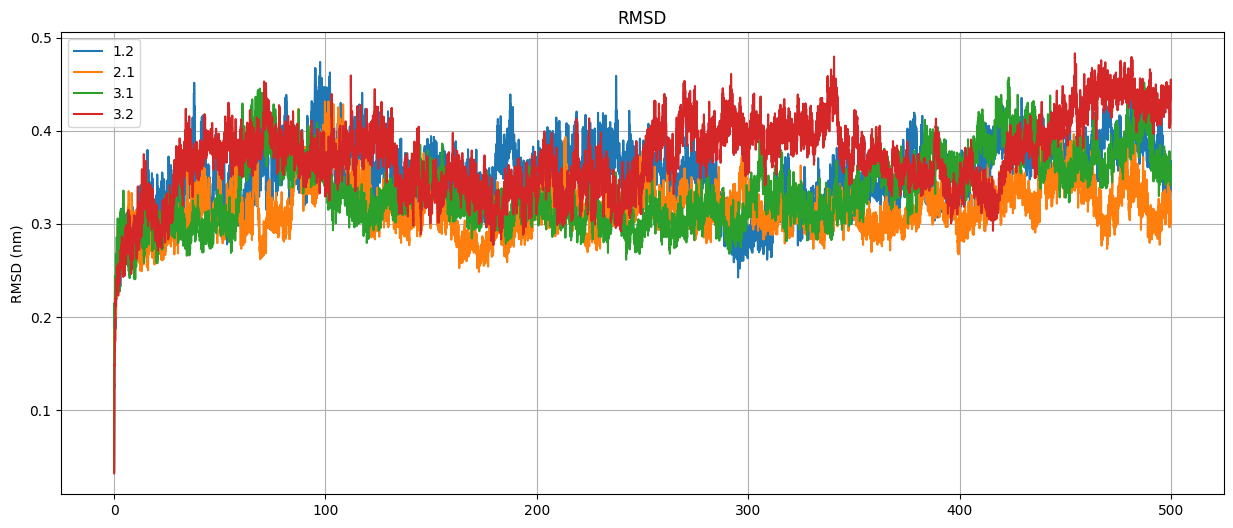

In [16]:
charge=["1.2","2.1","3.1","3.2"]

plt.figure(figsize=(15, 6))
plt.grid()
plt.ylabel("RMSD (nm)")
plt.title("RMSD")

def load_rmsd(charges):
    for charge in charges:
        data = np.loadtxt(f'post-processing/analysis-{charge}/rmsd/rmsd-fit.xvg', skiprows=18)
        time = data[:, 0]
        rmsd = data[:, 1]
        plt.plot(time, rmsd, label=f'{charge}')
        
load_rmsd(charge)
plt.legend()
plt.show()

# 2. RMSF

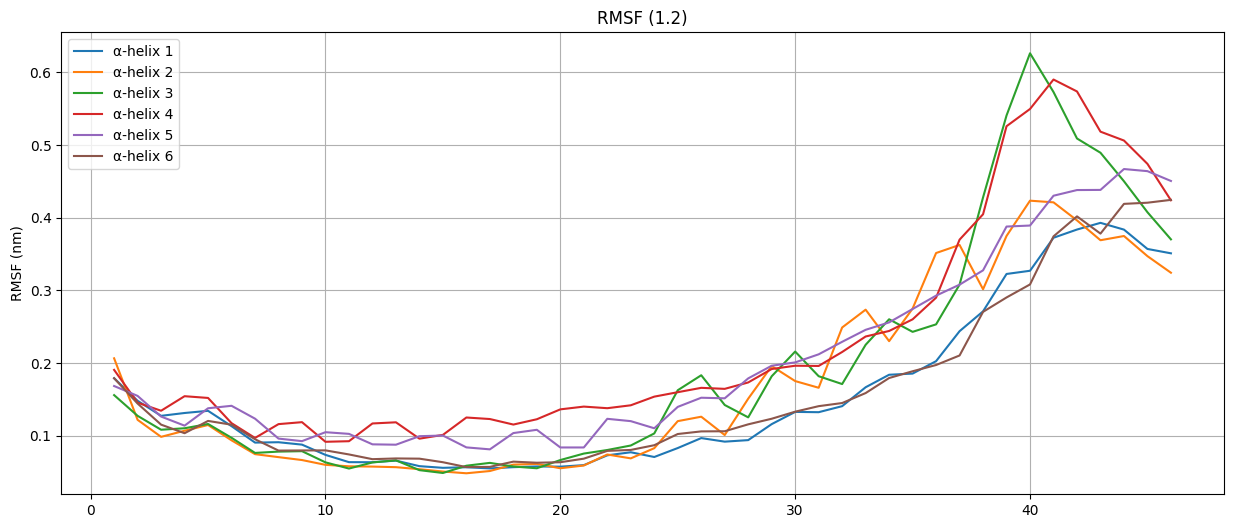

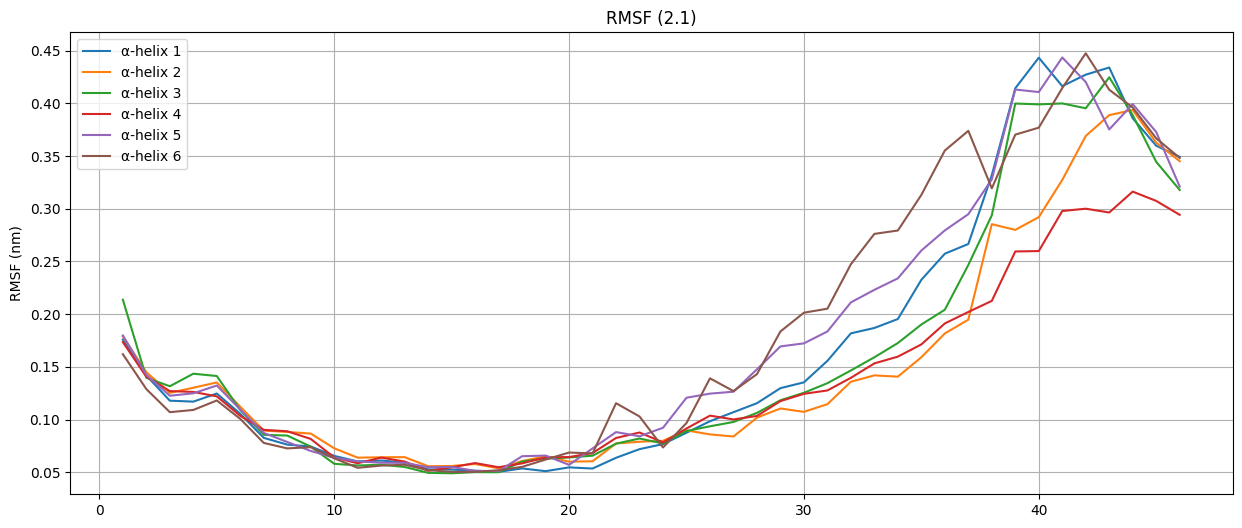

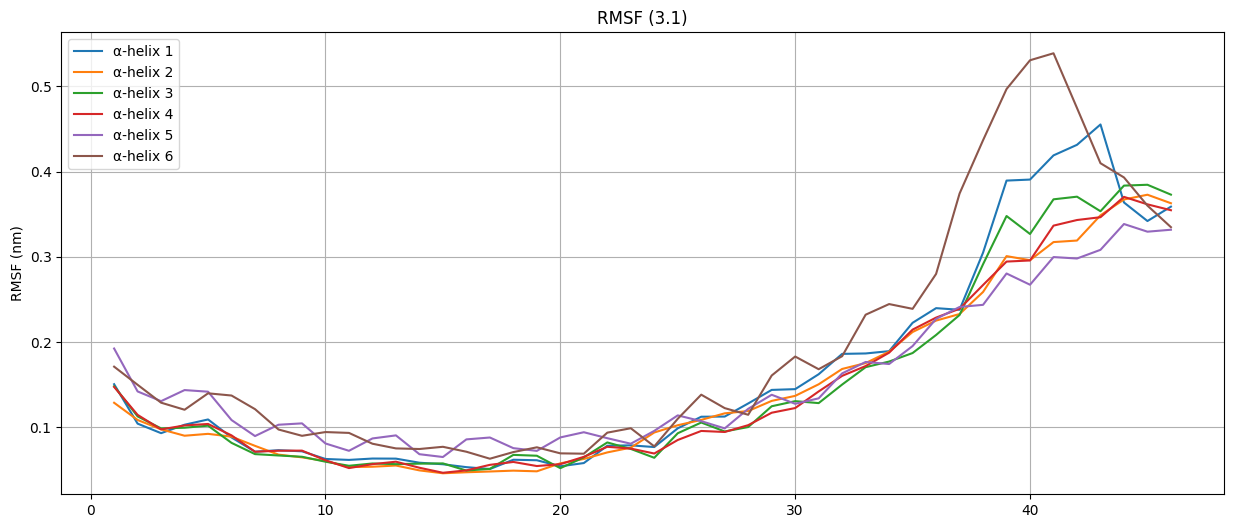

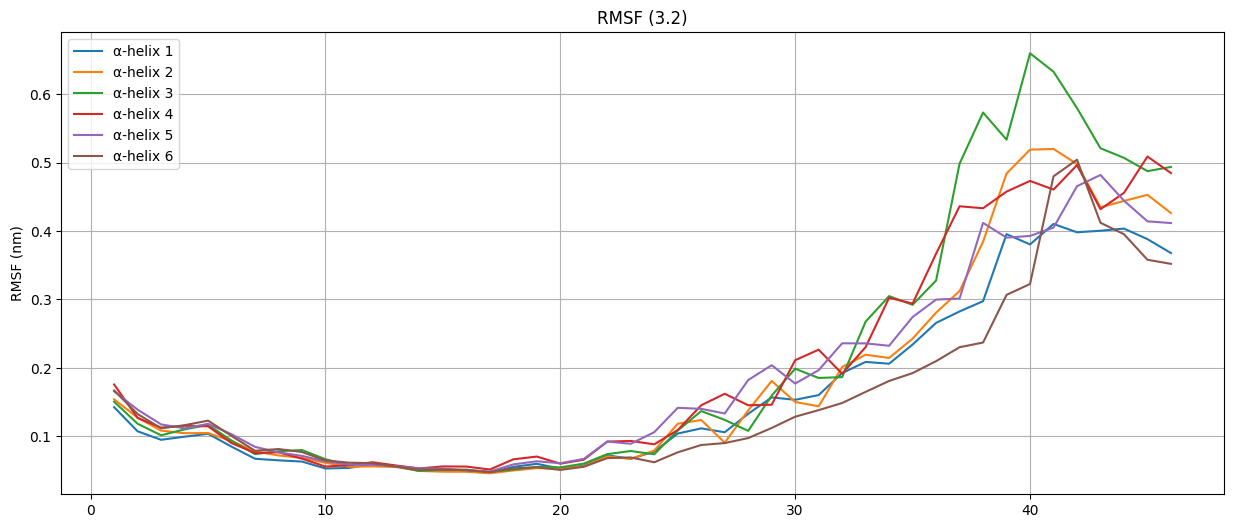

In [19]:
def load_rmsf(charges):
    for charge in charges:
        plt.figure(figsize=(15, 6))
        plt.grid()
        plt.ylabel("RMSF (nm)")
        plt.title(f"RMSF ({charge})")
        data = np.loadtxt(f'post-processing/analysis-run{charge}/rmsd/rmsf.xvg', skiprows=17)
        for i in range(0, len(data), 46):
            segment = data[i:i+46]
            resno = segment[:, 0]
            rmsf = segment[:, 1]
            plt.plot(resno, rmsf, label=f'α-helix {i//46 + 1}')
        plt.legend()
        plt.show()
        
load_rmsf(charge)

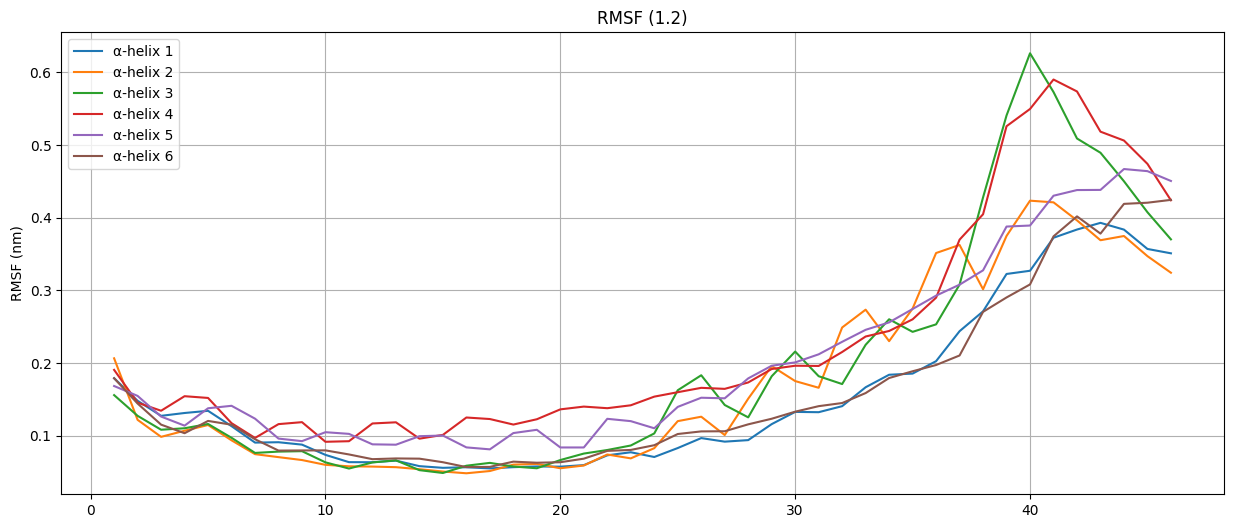

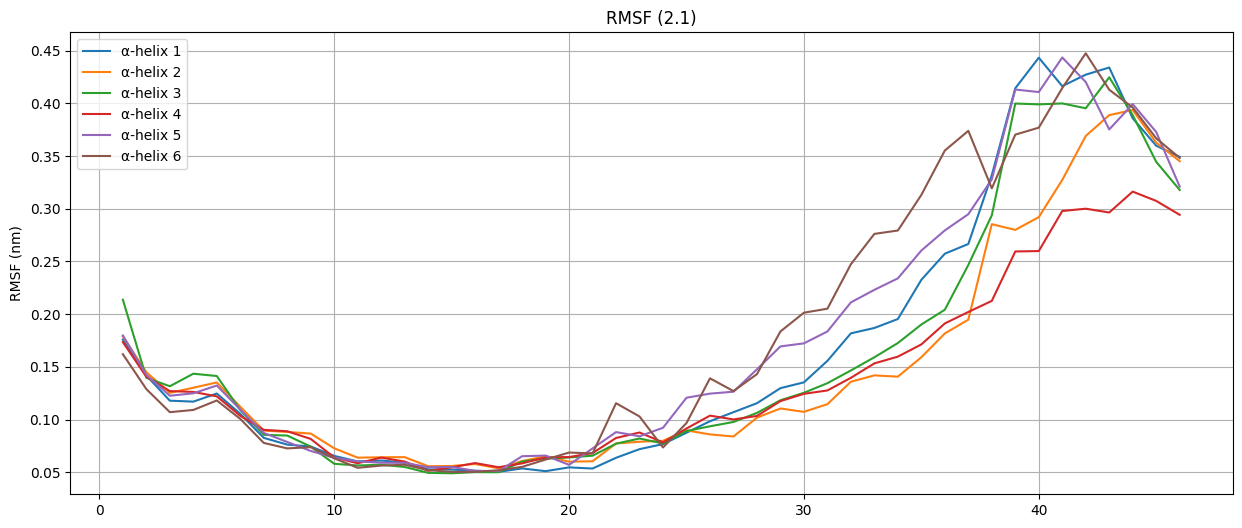

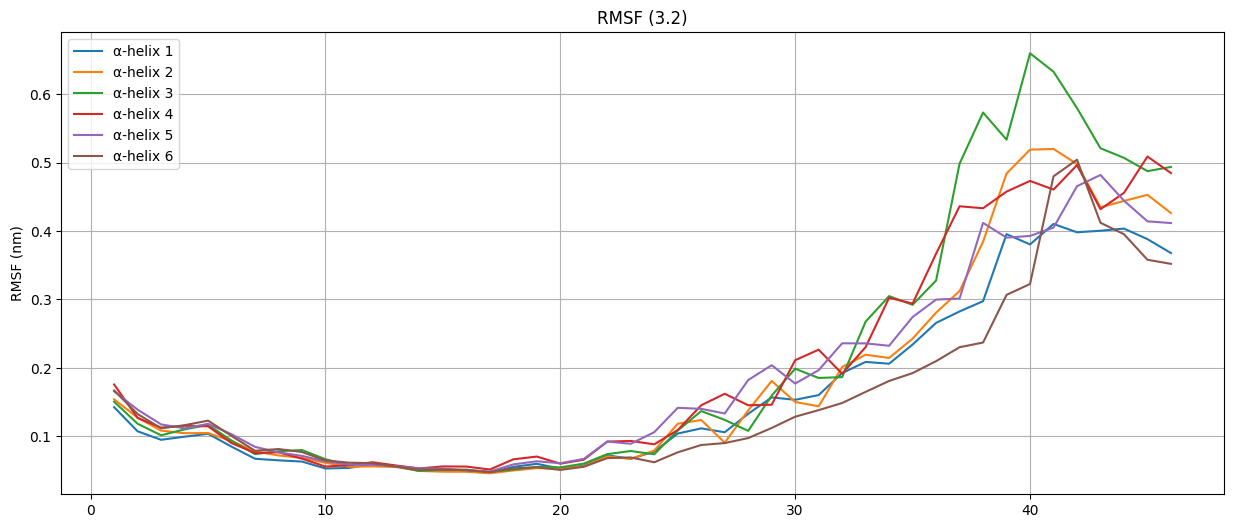

In [15]:
charges=["1.2","2.1","3.2"]
def load_rmsf2(charges):
    for charge in charges:
        plt.figure(figsize=(15, 6))
        plt.grid()
        plt.ylabel("RMSF (nm)")
        plt.title(f"RMSF ({charge})")
        data = np.loadtxt(f'post-processing/analysis-run{charge}/rmsd/rmsf.xvg', skiprows=17)
        for i in range(0, len(data), 46):
            segment = data[i:i+46]
            resno = segment[:, 0]
            rmsf = segment[:, 1]
            plt.plot(resno, rmsf, label=f'α-helix {i//46 + 1}')
        plt.legend()
        plt.show()
        
load_rmsf2(charges)

# 5. Radius of gyration

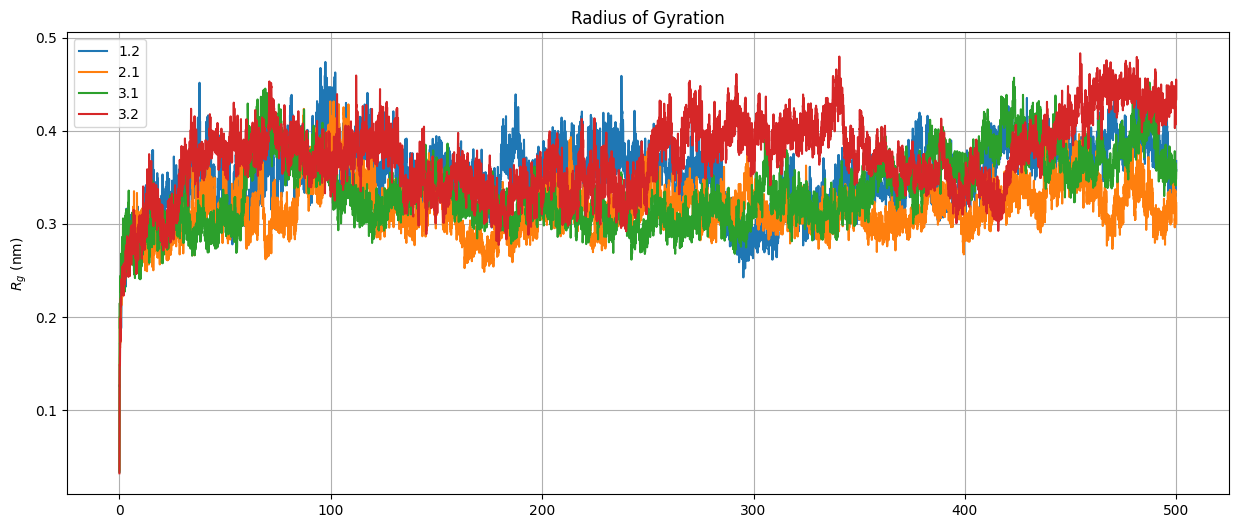

In [21]:
plt.figure(figsize=(15, 6))
plt.grid()
plt.ylabel(r"$R_g$ (nm)")
plt.title("Radius of Gyration")

def load_rg(runs):
    for run in runs:
        data = np.loadtxt(f'post-processing/analysis-run{run}/rmsd/gyrate.xvg', skiprows=27)
        time = data[:, 0]
        rg = data[:, 1]
        plt.plot(time, rg, label=f'{run}')

load_rmsd(charge)
plt.legend()
plt.show()